## Heart Disease Prediction Using Machine Learning

In this project, I will build a machine learning model to predict the possibility of heart attack based on medical information of patients.

The dataset contains different health-related features such as age, gender, blood pressure, cholesterol level, heart rate, and other medical indicators.

The main goal of this project is to classify patients into two groups:

* **0:** Low chance of heart attack
* **1:** High chance of heart attack

To achieve this goal, I will train and compare several classification algorithms, including Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, and Support Vector Machine (SVM).

Finally, I will evaluate the models using different performance metrics and select the best-performing model.


## Import Required Libraries

In this section, I import the necessary libraries required for data analysis, visualization, machine learning model development, and model evaluation.


In [2]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Load the Dataset

In this step, I load the dataset into the notebook and perform an initial inspection to ensure that it has been imported correctly. I also take a quick look at the first few rows to become familiar with the dataset's structure and features.


In [3]:
# Load dataset
heart_df = pd.read_csv("heart.csv")

# Display the first five rows
heart_df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Dataset Overview

Before building any machine learning model, it is important to understand the dataset. In this section, I examine the overall structure of the data, including the number of rows and columns, data types, descriptive statistics, and missing values.


In [4]:
# Dataset shape
print(f"Dataset Shape: {heart_df.shape}")

# General information
print(heart_df.info())

# Descriptive statistics
print(heart_df.describe())

Dataset Shape: (303, 14)
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None
              age         sex          cp      trtbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966

## Exploratory Data Analysis (EDA)

Before training any machine learning model, it is important to explore the dataset. In this section, I analyze the data to better understand its structure, identify potential issues such as missing or duplicate values, examine feature distributions, and investigate relationships between variables. This analysis provides valuable insights that guide the preprocessing and modeling stages.


### Check Missing Values

Missing values can negatively affect the performance of machine learning models. Therefore, I first check whether the dataset contains any missing values before proceeding with further analysis.


In [5]:
# Check missing values
heart_df.isnull().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

Result: The dataset does not contain any missing values, so no missing value treatment is required

### Check Duplicate Rows

Duplicate records may introduce bias during model training. In this step, I check whether the dataset contains duplicate rows before moving on to the next stage.


In [6]:
# Check duplicate rows
heart_df.duplicated().sum()

np.int64(1)

### Remove Duplicate Rows

The dataset contains one duplicate record. Since duplicate observations do not provide additional information and may introduce bias during model training, I remove the duplicate row before proceeding with the analysis.


In [7]:
# Remove duplicate rows
heart_df = heart_df.drop_duplicates()

# Verify that duplicates have been removed
heart_df.duplicated().sum()

np.int64(0)

### Target Variable Distribution

Before training the models, I examine the distribution of the target variable. Understanding the class distribution helps identify whether the dataset is balanced or imbalanced, which is important when selecting evaluation metrics and interpreting model performance.


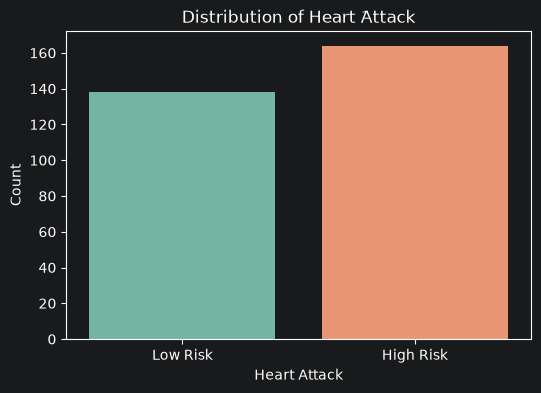

In [8]:
# Target variable distribution
plt.figure(figsize=(6, 4))

sns.countplot(data=heart_df, x='output', palette='Set2')

plt.title('Distribution of Heart َAttack')
plt.xlabel('Heart Attack')
plt.ylabel('Count')

plt.xticks([0, 1], ['Low Risk', 'High Risk'])

plt.show()

In [8]:
heart_df['output'].value_counts(normalize= True) * 100

output
1    54.304636
0    45.695364
Name: proportion, dtype: float64

### Interception

The target variable is relatively balanced, with both classes having a similar number of observations. Therefore, no special techniques for handling class imbalance are required.

### Feature Distribution

In this section, I examine the distribution of numerical features to better understand their patterns, spread, and potential outliers. This analysis provides valuable insights that can influence preprocessing decisions and model selection.


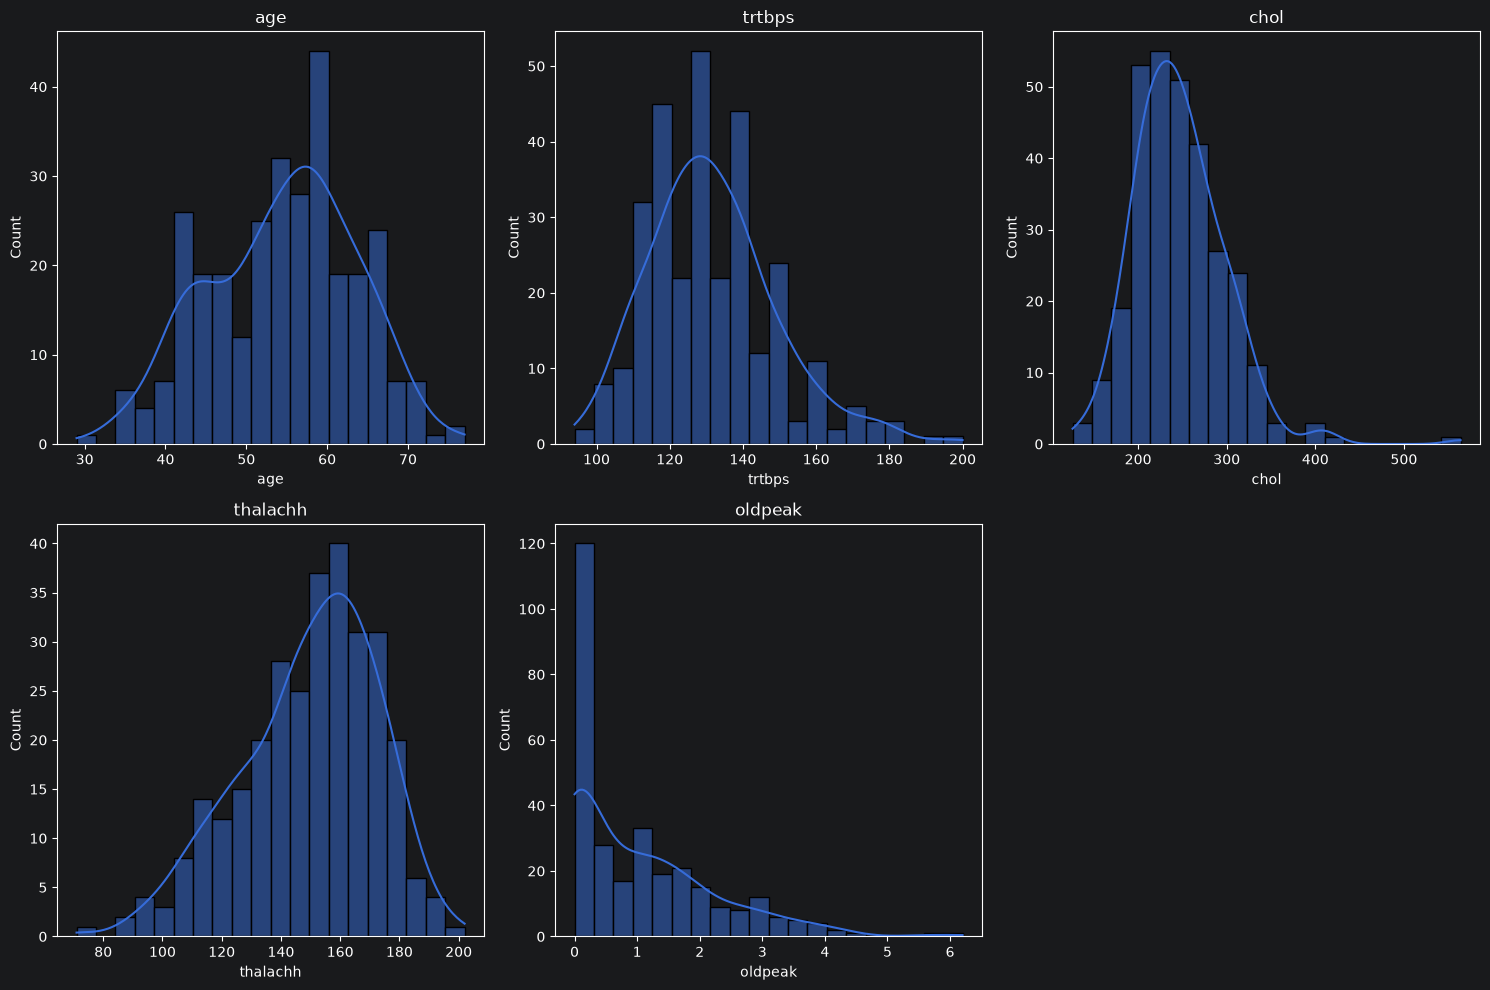

In [9]:
numerical_features = [
    'age',
    'trtbps',
    'chol',
    'thalachh',
    'oldpeak'
]

plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_features):
    plt.subplot(2,3,i+1)

    sns.histplot(
        heart_df[col],
        bins=20,
        kde=True
    )

    plt.title(col)

plt.tight_layout()
plt.show()

### Detecting Outliers

Boxplots provide a clear visualization of the distribution of numerical features and help identify potential outliers. Detecting these values is important because some machine learning algorithms are sensitive to extreme observations.


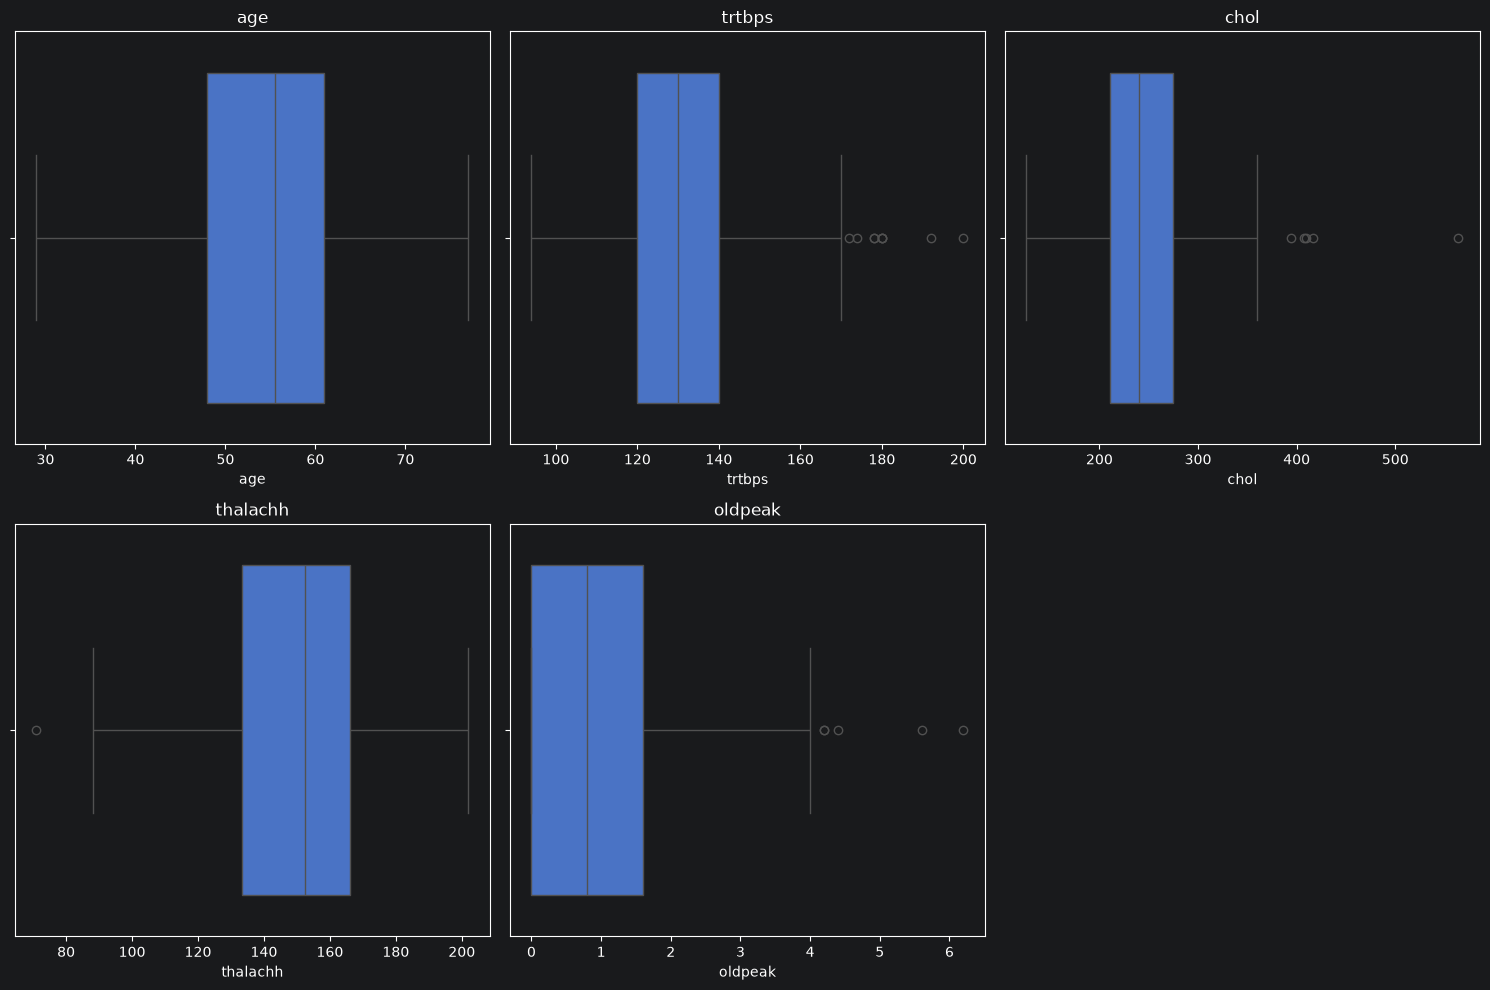

In [10]:
plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_features):
    plt.subplot(2,3,i+1)

    sns.boxplot(
        x=heart_df[col]
    )

    plt.title(col)

plt.tight_layout()
plt.show()

### Interpretation

Several numerical features contain potential outliers, particularly **trtbps**, **chol**, **thalachh**, and **oldpeak**. However, since this is a medical dataset, these extreme values may represent real clinical conditions rather than data entry errors. Therefore, no outliers are removed at this stage.

Removing medically valid extreme values could reduce the model's ability to recognize high-risk patients.

## Correlation Analysis

Correlation analysis helps identify relationships between numerical features and the target variable. It also allows us to detect highly correlated features, which may influence model performance and feature selection decisions.

In [11]:
# Correlation matrix
corr_matrix = heart_df.corr()

corr_matrix

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
age,1.000000,-0.094962,-0.063107,0.283121,0.207216,0.119492,-0.111590,-0.395235,0.093216,0.206040,-0.164124,0.302261,0.065317,-0.221476
sex,-0.094962,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609
cp,-0.063107,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080
trtbps,0.283121,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269
chol,0.207216,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437
fbs,0.119492,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826
restecg,-0.111590,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874
thalachh,-0.395235,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955
exng,0.093216,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601
oldpeak,0.206040,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146


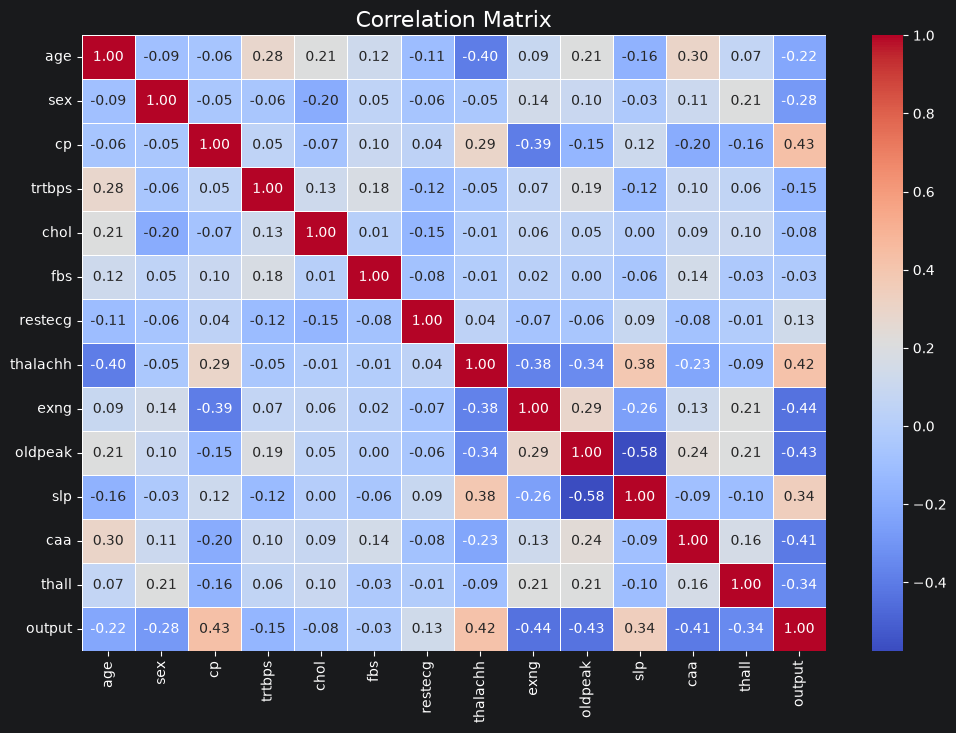

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=16)

plt.show()

### Correlation with the Target Variable

To better understand which features are most informative, I calculate the correlation between each feature and the target variable and sort the results in descending order.

In [13]:
corr_target = heart_df.corr()['output'].sort_values(ascending=False)

corr_target

output      1.000000
cp          0.432080
thalachh    0.419955
slp         0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trtbps     -0.146269
age        -0.221476
sex        -0.283609
thall      -0.343101
caa        -0.408992
oldpeak    -0.429146
exng       -0.435601
Name: output, dtype: float64

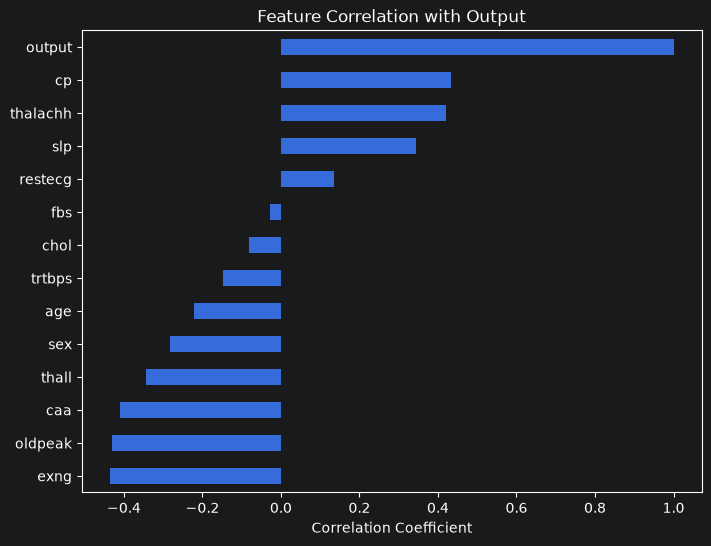

In [14]:
plt.figure(figsize=(8,6))

corr_target.sort_values().plot(kind='barh')

plt.title("Feature Correlation with Output")
plt.xlabel("Correlation Coefficient")

plt.show()

### Interpretation

The correlation analysis shows that **chest pain type (`cp`)**, **maximum heart rate (`thalachh`)**, and **ST slope (`slp`)** have the strongest positive relationships with the target variable. This indicates that these features may play an important role in predicting the presence of heart disease.

On the other hand, **exercise-induced angina (`exng`)**, **oldpeak**, and **number of major vessels (`caa`)** show the strongest negative correlations with the target variable. These features are also expected to contribute significantly to the prediction task.

Overall, no pair of features appears to have an extremely high correlation with each other, suggesting that multicollinearity is not a major concern in this dataset.

## Data Preprocessing

Before training the machine learning models, the dataset needs to be prepared. In this section, I separate the input features from the target variable, split the dataset into training and testing sets, and apply feature scaling where necessary. These preprocessing steps help ensure a fair and reliable evaluation of the models.

### Define Features and Target

The input features (`X`) contain all predictor variables, while the target variable (`y`) represents the output that the models are trained to predict.

In [15]:
# Features
X = heart_df.drop('output', axis=1)

# Target
y = heart_df['output']

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Feature Matrix Shape: (302, 13)
Target Vector Shape: (302,)


### Split the Dataset

To evaluate the models fairly, I split the dataset into training and testing sets. The models are trained using 80% of the data and evaluated on the remaining 20%.

A fixed `random_state` is used to ensure reproducibility, meaning the same data split is generated every time the notebook is executed.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (241, 13)
Testing Set : (61, 13)


### Feature Scaling

Some machine learning algorithms are sensitive to the scale of the features. For example, KNN and SVM use distance calculations, so features with larger values can have more influence on the model.

I used `StandardScaler` to standardize the features. The scaler is fitted only on the training data and then applied to both training and testing sets to prevent data leakage.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Training data after scaling:")
print(X_train_scaled[:5])

Training data after scaling:
[[ 0.28906186 -1.47344923 -0.93569147 -0.19208565  1.22278352 -0.40527917
  -1.04199213  0.40512154 -0.71813875 -0.88967624  0.96461102  0.26403574
  -0.5751421 ]
 [ 1.26718225  0.67867965  0.06210342  1.59054316  0.03543799 -0.40527917
   0.84612895 -1.36427316  1.39248856 -0.88967624 -0.63863902  2.22196228
  -2.24513302]
 [ 0.07170177 -1.47344923 -0.93569147 -0.19208565 -0.81861756 -0.40527917
   2.73425003 -0.91058221  1.39248856  0.77178811 -0.63863902  0.26403574
   1.09484882]
 [ 0.28906186  0.67867965 -0.93569147 -1.19481435  1.88936346 -0.40527917
   0.84612895 -0.32078397  1.39248856  1.60252028 -0.63863902  0.26403574
   1.09484882]
 [ 0.3977419   0.67867965  1.0598983   0.47640015 -0.69363382  2.46743496
  -1.04199213  0.67733611 -0.71813875 -0.88967624  0.96461102 -0.71492753
  -0.5751421 ]]


### Interpretation

The features have been successfully standardized.

The training and testing data are now ready for models that are sensitive to feature scaling, such as KNN and SVM.

### Logistic Regression Model

I started with Logistic Regression as a baseline classification model.

This model is used to predict whether a patient has a low or high chance of having a heart disease based on the given features.

In [18]:
from sklearn.linear_model import LogisticRegression

# Create and train the model
logreg = LogisticRegression(max_iter=1000)

logreg.fit(X_train_scaled, y_train)

# Make predictions
yhat_logreg = logreg.predict(X_test_scaled)

yhat_logreg[:10]

array([0, 0, 0, 1, 1, 0, 1, 0, 1, 1])

### Interpretation

The Logistic Regression model has been successfully trained and used to make predictions on the test data.

The predicted values represent the model's classification of patients into low-risk and high-risk groups.

### Logistic Regression Evaluation

I evaluated the Logistic Regression model using different classification metrics.

Besides accuracy, I also checked precision, recall, and F1-score to get a better understanding of the model performance.

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, yhat_logreg)
precision = precision_score(y_test, yhat_logreg)
recall = recall_score(y_test, yhat_logreg)
f1 = f1_score(y_test, yhat_logreg)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("Classification Report:")
print(classification_report(y_test, yhat_logreg))

Accuracy: 0.7868852459016393
Precision: 0.7631578947368421
Recall: 0.8787878787878788
F1-score: 0.8169014084507042
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.68      0.75        28
           1       0.76      0.88      0.82        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.78        61



### Interpretation

The Logistic Regression model was evaluated using multiple performance metrics.

Accuracy shows the overall correctness of the predictions, while recall is especially important in this project because missing a high-risk patient can be more critical.

### Store Model Performance

I stored the evaluation results of the Logistic Regression model to compare it with other models later.

In [20]:
model_results = []

model_results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
})

model_results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.7868852459016393,
  'Precision': 0.7631578947368421,
  'Recall': 0.8787878787878788,
  'F1-score': 0.8169014084507042}]

### K-Nearest Neighbors (KNN)

I trained a K-Nearest Neighbors (KNN) model as another classification approach.

Since KNN is based on distance calculations, I used the scaled training and testing data for this model.

In [21]:
from sklearn.neighbors import KNeighborsClassifier

# Create the KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train_scaled, y_train)

# Make predictions
yhat_knn = knn.predict(X_test_scaled)

yhat_knn[:10]

array([0, 1, 0, 0, 1, 0, 1, 1, 1, 1])

### Interpretation

The KNN model has been successfully trained and used to make predictions on the test data.

The predicted values represent the classification of patients into low-risk and high-risk groups.

### KNN Model Evaluation

I evaluated the performance of the KNN model using different classification metrics.

I calculated accuracy, precision, recall, and F1-score to compare its performance with other models later.

In [22]:
accuracy_knn = accuracy_score(y_test, yhat_knn)
precision_knn = precision_score(y_test, yhat_knn)
recall_knn = recall_score(y_test, yhat_knn)
f1_knn = f1_score(y_test, yhat_knn)

print("Accuracy:", accuracy_knn)
print("Precision:", precision_knn)
print("Recall:", recall_knn)
print("F1-score:", f1_knn)

print("\nClassification Report:")
print(classification_report(y_test, yhat_knn))

Accuracy: 0.8032786885245902
Precision: 0.7692307692307693
Recall: 0.9090909090909091
F1-score: 0.8333333333333334

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



### Interpretation

The KNN model was evaluated using multiple performance metrics.

These results will be stored and compared with other models to select the best-performing model for this classification task.

### Store KNN Performance

I stored the evaluation results of the KNN model to compare it with the other trained models later.

In [23]:
model_results.append({
    "Model": "KNN",
    "Accuracy": accuracy_knn,
    "Precision": precision_knn,
    "Recall": recall_knn,
    "F1-score": f1_knn
})

model_results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.7868852459016393,
  'Precision': 0.7631578947368421,
  'Recall': 0.8787878787878788,
  'F1-score': 0.8169014084507042},
 {'Model': 'KNN',
  'Accuracy': 0.8032786885245902,
  'Precision': 0.7692307692307693,
  'Recall': 0.9090909090909091,
  'F1-score': 0.8333333333333334}]

### Support Vector Machine (SVM)

I trained a Support Vector Machine (SVM) model as another classification approach.

SVM finds the best decision boundary between classes to classify patients into low-risk and high-risk groups.

In [24]:
from sklearn.svm import SVC

# Create the SVM model
svm = SVC(kernel='rbf')

# Train the model
svm.fit(X_train_scaled, y_train)

# Make predictions
yhat_svm = svm.predict(X_test_scaled)

yhat_svm[:10]

array([0, 0, 0, 1, 1, 0, 1, 0, 1, 1])

### Interpretation

The SVM model has been successfully trained and used to make predictions on the test data.

The output represents the predicted class for each patient.

### SVM Model Evaluation

I evaluated the performance of the SVM model using different classification metrics.

These metrics help me better understand the model performance and compare it with other models.

In [25]:
accuracy_svm = accuracy_score(y_test, yhat_svm)
precision_svm = precision_score(y_test, yhat_svm)
recall_svm = recall_score(y_test, yhat_svm)
f1_svm = f1_score(y_test, yhat_svm)

print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1-score:", f1_svm)

print("\nClassification Report:")
print(classification_report(y_test, yhat_svm))

Accuracy: 0.8360655737704918
Precision: 0.7948717948717948
Recall: 0.9393939393939394
F1-score: 0.8611111111111112

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80        28
           1       0.79      0.94      0.86        33

    accuracy                           0.84        61
   macro avg       0.85      0.83      0.83        61
weighted avg       0.85      0.84      0.83        61



### Interpretation

The SVM model was evaluated using multiple performance metrics.

The results will be stored and compared with other models to select the best-performing model for this project.

### Store SVM Performance

I stored the evaluation results of the SVM model to compare it with the other trained models later.

In [26]:
model_results.append({
    "Model": "SVM",
    "Accuracy": accuracy_svm,
    "Precision": precision_svm,
    "Recall": recall_svm,
    "F1-score": f1_svm
})

model_results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.7868852459016393,
  'Precision': 0.7631578947368421,
  'Recall': 0.8787878787878788,
  'F1-score': 0.8169014084507042},
 {'Model': 'KNN',
  'Accuracy': 0.8032786885245902,
  'Precision': 0.7692307692307693,
  'Recall': 0.9090909090909091,
  'F1-score': 0.8333333333333334},
 {'Model': 'SVM',
  'Accuracy': 0.8360655737704918,
  'Precision': 0.7948717948717948,
  'Recall': 0.9393939393939394,
  'F1-score': 0.8611111111111112}]

### Decision Tree Model

I trained a Decision Tree model as another classification approach.

Unlike KNN and SVM, Decision Tree does not depend on distance calculations, so I used the original data without scaling.

In [27]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
tree_model = DecisionTreeClassifier(criterion='entropy',max_depth=5)

# Train the model
tree_model.fit(X_train, y_train)

# Make predictions
yhat_tree = tree_model.predict(X_test)

yhat_tree[:10]

array([0, 0, 0, 1, 1, 0, 1, 0, 1, 1])

### Interpretation

The Decision Tree model has been successfully trained and used to make predictions on the test data.

The predictions represent the classification of patients into low-risk and high-risk groups.

## Decition Tree Model Visualization

In this section, I will display the decision tree diagram.

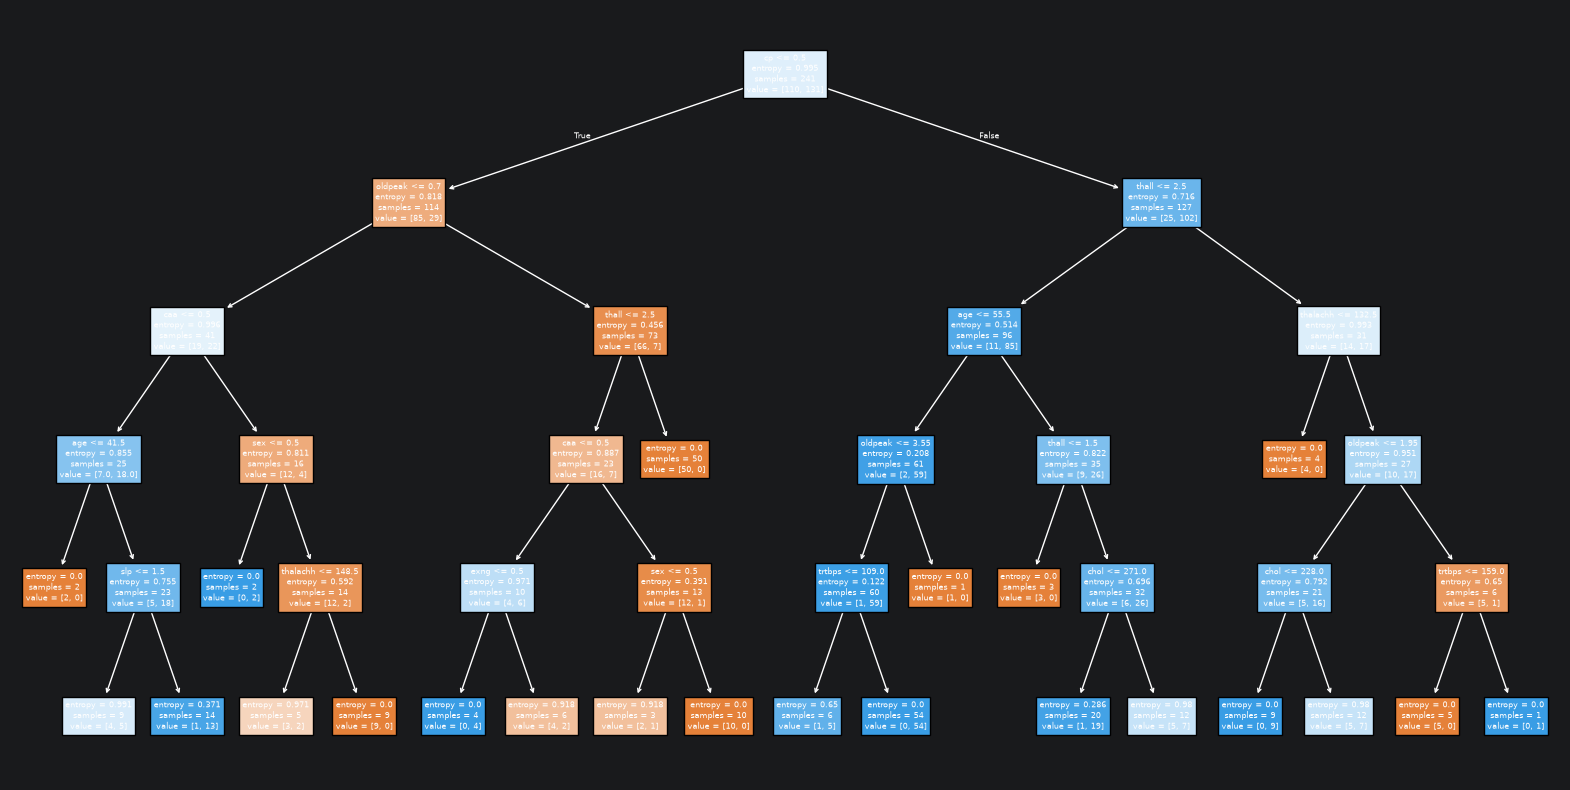

In [30]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

tree.plot_tree(
    tree_model,
    feature_names=X.columns,
    filled=True
)

plt.show()

### Decision Tree Model Evaluation

I evaluated the performance of the Decision Tree model using different classification metrics.

These results will be used later to compare this model with the other trained models.

In [29]:
accuracy_tree = accuracy_score(y_test, yhat_tree)
precision_tree = precision_score(y_test, yhat_tree)
recall_tree = recall_score(y_test, yhat_tree)
f1_tree = f1_score(y_test, yhat_tree)

print("Accuracy:", accuracy_tree)
print("Precision:", precision_tree)
print("Recall:", recall_tree)
print("F1-score:", f1_tree)

print("\nClassification Report:")
print(classification_report(y_test, yhat_tree))

Accuracy: 0.8360655737704918
Precision: 0.7804878048780488
Recall: 0.9696969696969697
F1-score: 0.8648648648648649

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.68      0.79        28
           1       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61



### Store Decision Tree Performance

I stored the evaluation results of the Decision Tree model to compare it with the other models later.

In [30]:
model_results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_tree,
    "Precision": precision_tree,
    "Recall": recall_tree,
    "F1-score": f1_tree
})

model_results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.7868852459016393,
  'Precision': 0.7631578947368421,
  'Recall': 0.8787878787878788,
  'F1-score': 0.8169014084507042},
 {'Model': 'KNN',
  'Accuracy': 0.8032786885245902,
  'Precision': 0.7692307692307693,
  'Recall': 0.9090909090909091,
  'F1-score': 0.8333333333333334},
 {'Model': 'SVM',
  'Accuracy': 0.8360655737704918,
  'Precision': 0.7948717948717948,
  'Recall': 0.9393939393939394,
  'F1-score': 0.8611111111111112},
 {'Model': 'Decision Tree',
  'Accuracy': 0.8360655737704918,
  'Precision': 0.7804878048780488,
  'Recall': 0.9696969696969697,
  'F1-score': 0.8648648648648649}]

### Model Comparison

I collected the performance results of all trained models into a single table.

This allows me to compare the models based on different evaluation metrics and select the most suitable model for this classification task.

In [31]:
import pandas as pd

results_df = pd.DataFrame(model_results)

results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.786885,0.763158,0.878788,0.816901
1,KNN,0.803279,0.769231,0.909091,0.833333
2,SVM,0.836066,0.794872,0.939394,0.861111
3,Decision Tree,0.836066,0.780488,0.969697,0.864865


### Model Performance Visualization

I visualized the evaluation metrics of all models to better compare their performance.

This helps identify which model achieved better results across different metrics.

<Figure size 1000x600 with 0 Axes>

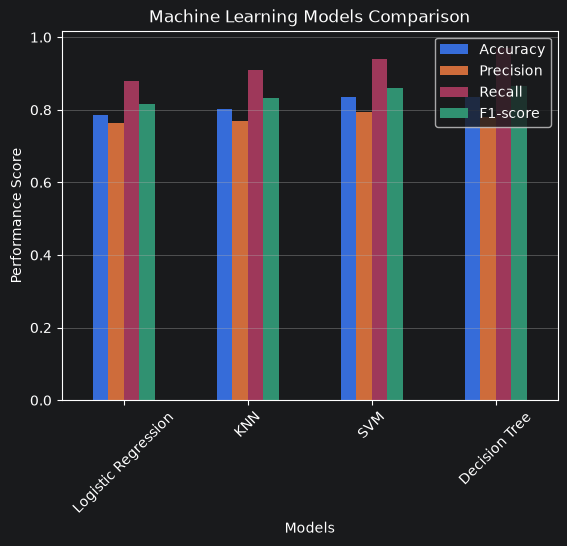

In [37]:
plt.figure(figsize=(10,6))

results_df.set_index("Model").plot(
    kind="bar"
)

plt.title("Machine Learning Models Comparison")
plt.xlabel("Models")
plt.ylabel("Performance Score")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.legend(loc='best')
plt.show()

### Interpretation

The model comparison shows that each algorithm has different strengths.

Although accuracy is important, recall is especially important in this medical prediction task because missing a high-risk patient can be more critical.

Based on the evaluation results, the Decision Tree model achieved the highest recall and F1-score, making it a strong candidate for heart disease risk prediction.

However, the final model selection should consider the balance between all evaluation metrics.

## Confusion Matrix Evaluation

To better evaluate the Decision Tree model, I used a confusion matrix to analyze correct and incorrect predictions.

It shows True Positive, True Negative, False Positive, and False Negative results, which helps to understand the model's performance, especially in medical prediction tasks where missing a real patient is important.

<Figure size 640x480 with 0 Axes>

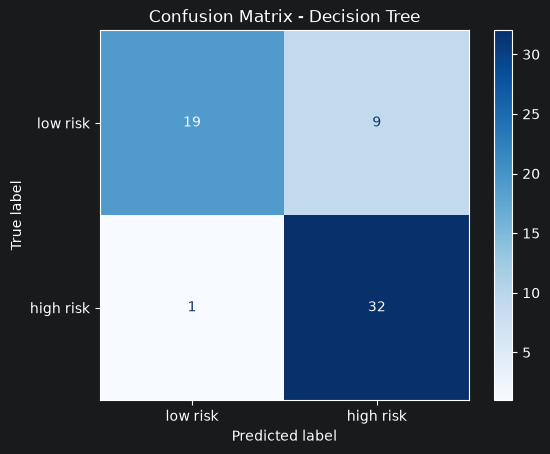

[[19  9]
 [ 1 32]]


In [40]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from matplotlib import pyplot as plt
cnf_matrix = confusion_matrix(y_test, yhat_tree, labels=[0, 1])
np.set_printoptions(precision=2)
plt.figure()
# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cnf_matrix,
    display_labels=['low risk', 'high risk']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

## Conclusion

In this project, I built a machine learning classification system to predict the risk of heart disease based on patient medical information.

I performed data exploration and preprocessing, then trained and evaluated different classification models, including Logistic Regression, KNN, SVM, and Decision Tree.

The models were compared using different evaluation metrics such as accuracy, precision, recall, and F1-score.

Since this is a medical prediction task, recall was considered an important metric because correctly identifying high-risk patients is more critical.

Based on the evaluation results, the Decision Tree model achieved the best overall performance in this project and was selected as the recommended model for heart disease risk prediction.

## Future Improvements

This project can be improved in the future by applying techniques such as hyperparameter tuning, cross-validation, and testing more advanced machine learning algorithms.

These improvements can help achieve better generalization and improve the model performance on unseen data.

👨‍💻 Author

Created by Mehdi Ferdosi

Computer Science Student | Machine Learning Learner

⭐ Thanks for checking out this project